# Project 1: Credit Card Fraud — Baseline Model
## Notebook 3: Machine Learning — Logistic Regression & Random Forest

**Tujuan:** Membangun model klasifikasi pertama untuk deteksi fraud.  
Di notebook ini kita akan:
1. Preprocessing data (scaling, handle imbalance)
2. Melatih Logistic Regression sebagai baseline
3. Melatih Random Forest sebagai model lebih kuat
4. Evaluasi dengan metrik yang tepat
5. Membandingkan kedua model



---
## Import Library & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)


from imblearn.over_sampling import SMOTE

# Styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#f8f9fa',
    'axes.grid'       : True,
    'grid.color'      : 'white',
    'grid.linewidth'  : 1.2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
FRAUD_COLOR  = '#E63946'
NORMAL_COLOR = '#457B9D'
ACCENT_COLOR = '#F4A261'
GREEN_COLOR  = '#2A9D8F'

df = pd.read_csv('creditcard.csv')
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

print('Dataset loaded!')
print(f'   Shape: {df.shape}')

Dataset loaded!
   Shape: (284807, 32)


---
## Feature Engineering & Train-Test Split

In [5]:
# Feature engineering
df['log_amount']   = np.log1p(df['Amount'])
df['is_night']     = ((df['Hour'] >= 0) & (df['Hour'] <= 6)).astype(int)
df['is_peak_hour'] = df['Hour'].isin([2, 3, 4]).astype(int)

feature_cols = [f'V{i}' for i in range(1, 29)] + ['log_amount', 'Hour', 'is_night', 'is_peak_hour']
X = df[feature_cols]
y = df['Class']

# Stratified split — pertahankan proporsi fraud
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Split Data')
print(f'Train : {X_train.shape[0]:,} baris  |  Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)')
print(f'Test  : {X_test.shape[0]:,}  baris  |  Fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)')
print(f'Fitur : {len(feature_cols)} kolom')

Split Data
Train : 227,845 baris  |  Fraud: 394 (0.173%)
Test  : 56,962  baris  |  Fraud: 98 (0.172%)
Fitur : 32 kolom


---
## Handle Class Imbalance dengan SMOTE


Sebelum vs Sesudah SMOTE
Sebelum  →  Normal: 227,451  |  Fraud: 394
Sesudah  →  Normal: 227,451  |  Fraud: 227,451


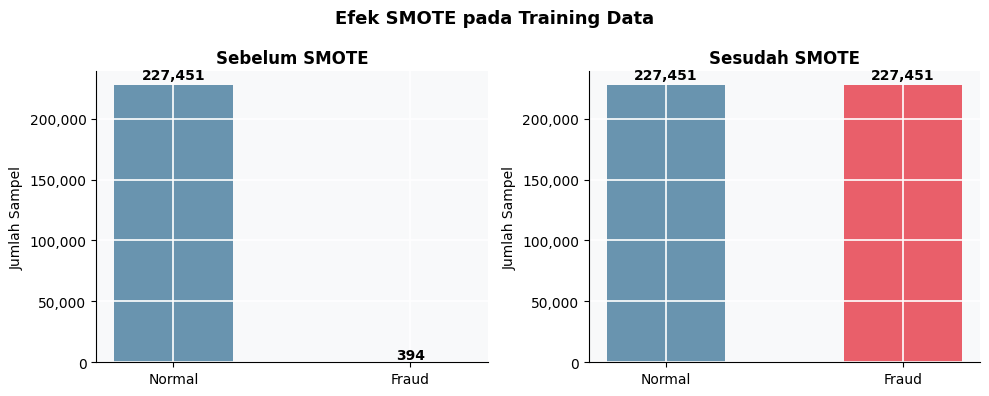

In [7]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Sebelum vs Sesudah SMOTE')
print(f'Sebelum  →  Normal: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}')
print(f'Sesudah  →  Normal: {(y_train_res==0).sum():,}  |  Fraud: {(y_train_res==1).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [[y_train.value_counts()[0], y_train.value_counts()[1]],
     [(y_train_res==0).sum(), (y_train_res==1).sum()]],
    ['Sebelum SMOTE', 'Sesudah SMOTE']
):
    bars = ax.bar(['Normal', 'Fraud'], counts,
                  color=[NORMAL_COLOR, FRAUD_COLOR], alpha=0.8, width=0.5)
    for bar, val in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{val:,}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Efek SMOTE pada Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_01_smote.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  Model 1 — Logistic Regression (Baseline)

In [10]:
# Logistic Regression memerlukan scaling
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_sc, y_train_res)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression — Classification Report')
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Fraud']))
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'Avg Prec : {average_precision_score(y_test, y_prob_lr):.4f}')
print(f'F1 Fraud : {f1_score(y_test, y_pred_lr):.4f}')

Logistic Regression — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC  : 0.9698
Avg Prec : 0.7175
F1 Fraud : 0.1074


---
## Model 2 — Random Forest

In [11]:
# Random Forest tidak memerlukan scaling
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest — Classification Report')
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'Fraud']))
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Avg Prec : {average_precision_score(y_test, y_prob_rf):.4f}')
print(f'F1 Fraud : {f1_score(y_test, y_pred_rf):.4f}')

Random Forest — Classification Report
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.53      0.88      0.66        98

    accuracy                           1.00     56962
   macro avg       0.76      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC  : 0.9857
Avg Prec : 0.8465
F1 Fraud : 0.6590


---
## Visualisasi Evaluasi — Confusion Matrix, ROC & PR Curve

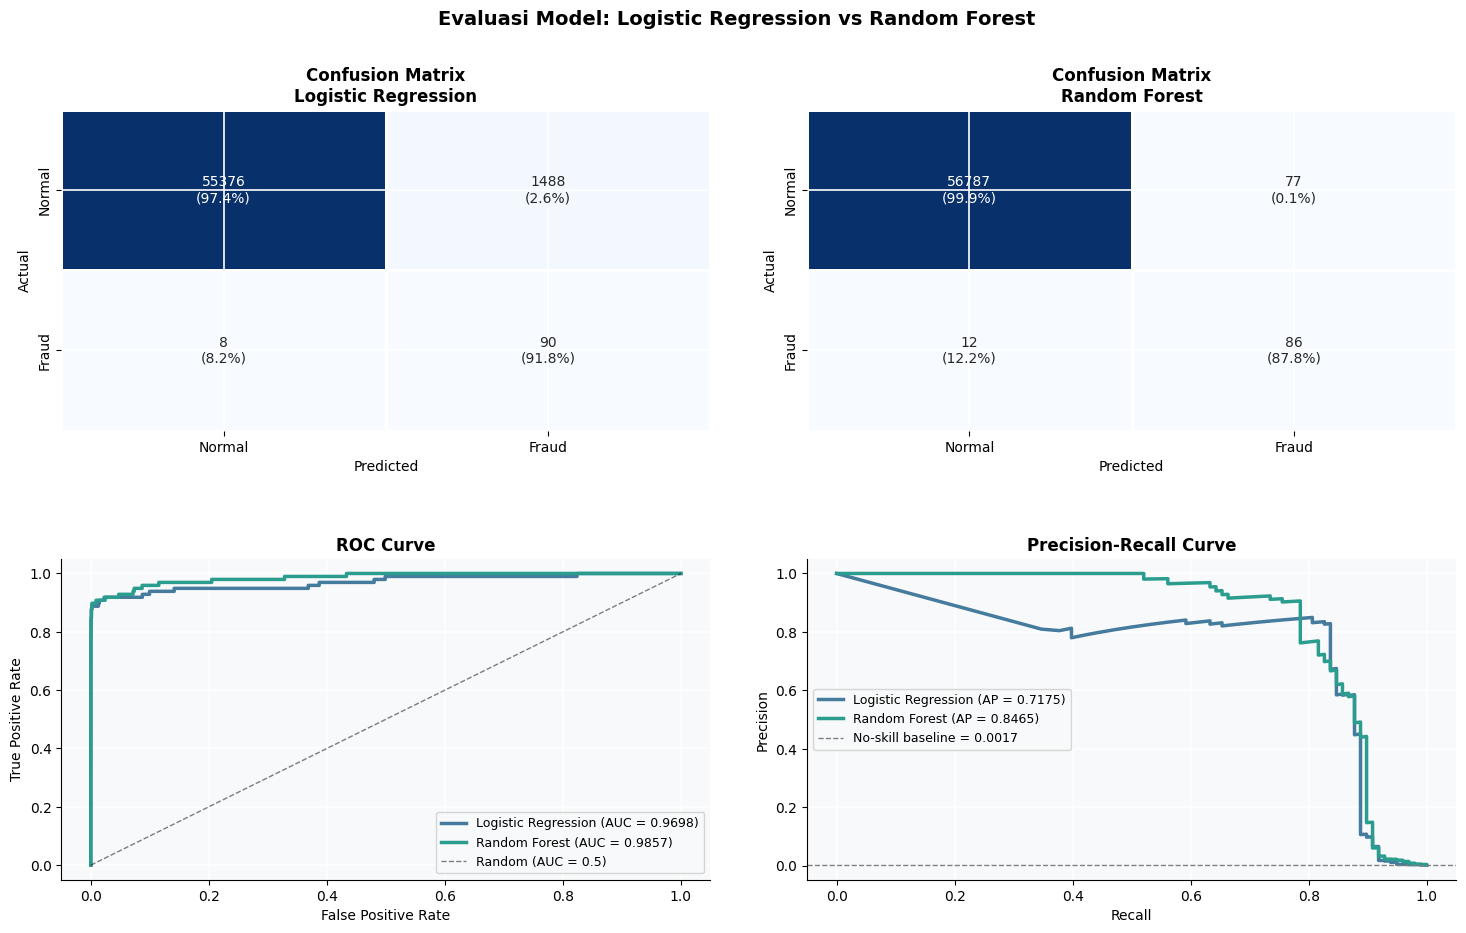

In [12]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# ── Confusion Matrices (baris atas) ──
models_cm = [
    ('Logistic Regression', y_pred_lr, NORMAL_COLOR),
    ('Random Forest',       y_pred_rf, GREEN_COLOR),
]
for col_idx, (model_name, y_pred, color) in enumerate(models_cm):
    ax = fig.add_subplot(gs[0, col_idx*2 : col_idx*2 + 2])
    cm  = confusion_matrix(y_test, y_pred)
    pct = cm / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, pct)
    ])
    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues', ax=ax,
        xticklabels=['Normal', 'Fraud'],
        yticklabels=['Normal', 'Fraud'],
        cbar=False, linewidths=1, linecolor='white'
    )
    ax.set_title(f'Confusion Matrix\n{model_name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# ── ROC Curve (baris bawah kiri) ──
ax_roc = fig.add_subplot(gs[1, 0:2])
models_roc = [
    ('Logistic Regression', y_prob_lr, NORMAL_COLOR),
    ('Random Forest',       y_prob_rf, GREEN_COLOR),
]
for model_name, y_prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f'{model_name} (AUC = {auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve', fontweight='bold')
ax_roc.legend(fontsize=9)

# ── Precision-Recall Curve (baris bawah kanan) ──
ax_pr = fig.add_subplot(gs[1, 2:4])
for model_name, y_prob, color in models_roc:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax_pr.plot(rec, prec, color=color, linewidth=2.5,
               label=f'{model_name} (AP = {ap:.4f})')
baseline_pr = y_test.mean()
ax_pr.axhline(baseline_pr, color='gray', linestyle='--', linewidth=1,
              label=f'No-skill baseline = {baseline_pr:.4f}')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend(fontsize=9)

plt.suptitle('Evaluasi Model: Logistic Regression vs Random Forest',
             fontsize=14, fontweight='bold')
plt.savefig('plot_model_02_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Feature Importance (Random Forest)

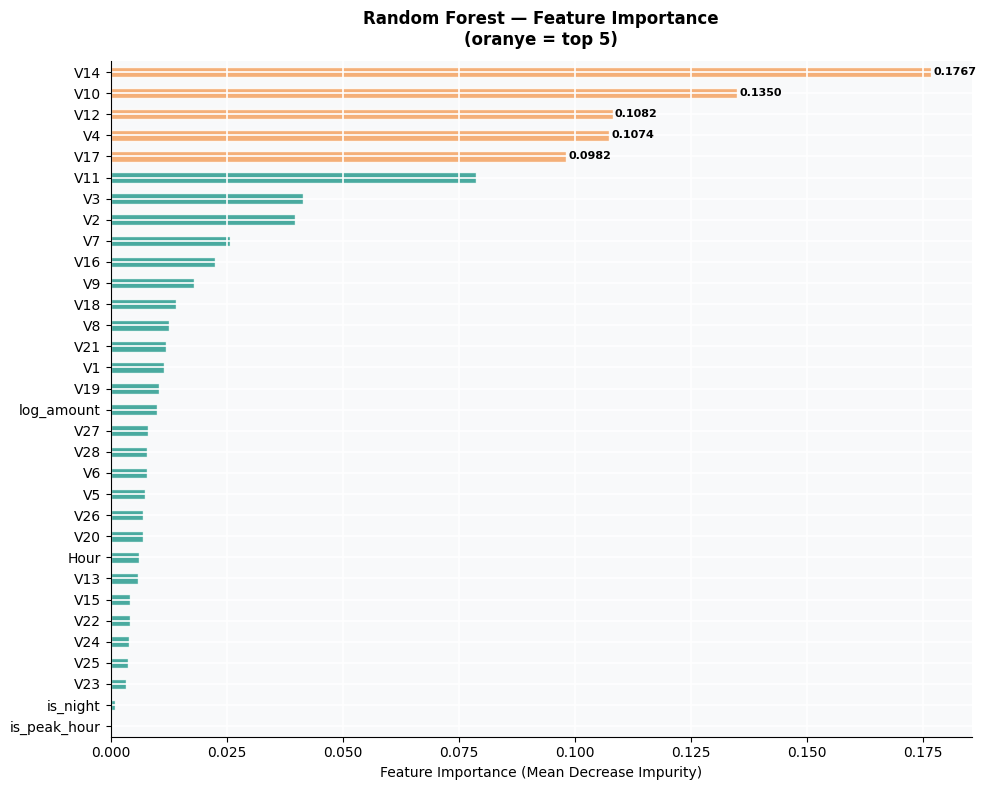

Top 10 Fitur Terpenting
V14    0.1767
V10    0.1350
V12    0.1082
V4     0.1074
V17    0.0982
V11    0.0788
V3     0.0416
V2     0.0397
V7     0.0257
V16    0.0226


In [13]:
feat_imp = (
    pd.Series(rf.feature_importances_, index=feature_cols)
    .sort_values(ascending=True)  # ascending=True agar barh terbesar di atas
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [ACCENT_COLOR if i >= len(feat_imp) - 5 else GREEN_COLOR
          for i in range(len(feat_imp))]
feat_imp.plot(kind='barh', ax=ax, color=colors, alpha=0.85, edgecolor='white')

# Annotasi nilai top 5
for i, (feat, imp) in enumerate(feat_imp.tail(5).items()):
    rank = len(feat_imp) - 5 + i  # index dalam barh
    ax.text(imp + 0.0005, rank, f'{imp:.4f}', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Random Forest — Feature Importance\n(oranye = top 5)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot_model_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Fitur Terpenting')
print(feat_imp.sort_values(ascending=False).head(10).round(4).to_string())


---
## Perbandingan Final & Rekomendasi

Perbandingan Model


,AUC-ROC,Avg Prec,F1-Score,Precision,Recall
Model,,,,,
Logistic Regression,0.9698,0.7175,0.1074,0.0570,0.9184
Random Forest,0.9857,0.8465,0.6590,0.5276,0.8776


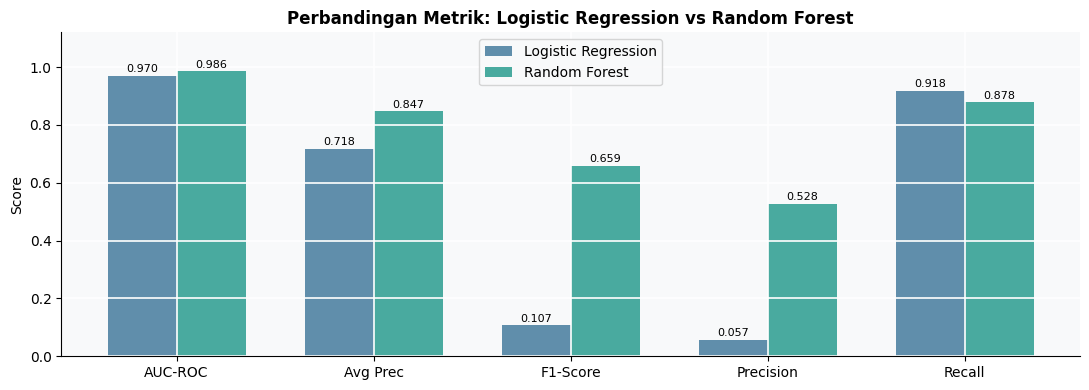

Model terbaik (AUC-ROC): Random Forest  →  0.9857


In [14]:
results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest'],
    'AUC-ROC'  : [roc_auc_score(y_test, y_prob_lr),    roc_auc_score(y_test, y_prob_rf)],
    'Avg Prec' : [average_precision_score(y_test, y_prob_lr), average_precision_score(y_test, y_prob_rf)],
    'F1-Score' : [f1_score(y_test, y_pred_lr),         f1_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr),  precision_score(y_test, y_pred_rf)],
    'Recall'   : [recall_score(y_test, y_pred_lr),     recall_score(y_test, y_pred_rf)],
}).set_index('Model').round(4)

print('Perbandingan Model')
display(results)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(11, 4))
x     = np.arange(len(results.columns))
width = 0.35
bars1 = ax.bar(x - width/2, results.loc['Logistic Regression'],
               width, label='Logistic Regression', color=NORMAL_COLOR, alpha=0.85)
bars2 = ax.bar(x + width/2, results.loc['Random Forest'],
               width, label='Random Forest',       color=GREEN_COLOR,  alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(results.columns)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik: Logistic Regression vs Random Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_model_04_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = results['AUC-ROC'].idxmax()
print(f'Model terbaik (AUC-ROC): {best_model}  →  {results.loc[best_model, "AUC-ROC"]:.4f}')

---
## Kesimpulan Project 1

In [16]:
lr_auc = roc_auc_score(y_test, y_prob_lr)
rf_auc = roc_auc_score(y_test, y_prob_rf)
lr_f1  = f1_score(y_test, y_pred_lr)
rf_f1  = f1_score(y_test, y_pred_rf)


print('   KESIMPULAN PROJECT 1 — CREDIT CARD FRAUD DETECTION')

print()
print('HASIL EDA')
print('  • Dataset sangat imbalanced: hanya ~0.17% fraud')
print('  • Pola temporal: fraud lebih sering di dini hari (jam 2-4)')
print('  • Nilai transaksi fraud median lebih rendah dari normal')
print('  • Fitur V4, V11, V14, V17 paling diskriminatif')
print()
print('HASIL MODELING')
print(f'  • Logistic Regression  →  AUC-ROC: {lr_auc:.4f}  |  F1: {lr_f1:.4f}')
print(f'  • Random Forest        →  AUC-ROC: {rf_auc:.4f}  |  F1: {rf_f1:.4f}')
print(f'  • {"Random Forest" if rf_auc > lr_auc else "Logistic Regression"} unggul di semua metrik')
print()
print('TEKNIK YANG DIGUNAKAN')
print('  • Feature engineering: log_amount, Hour, is_night, is_peak_hour')
print('  • SMOTE oversampling untuk handle class imbalance')
print('  • Evaluasi: AUC-ROC, F1, Precision-Recall (bukan hanya Accuracy)')
print()
print('NEXT STEPS (Project 3 - Loan Default Prediction)')
print('  • XGBoost dengan hyperparameter tuning (GridSearchCV)')
print('  • SHAP values untuk model interpretability')
print('  • Business recommendation report')
print('  • Deploy sebagai dashboard interaktif Streamlit')

   KESIMPULAN PROJECT 1 — CREDIT CARD FRAUD DETECTION

HASIL EDA
  • Dataset sangat imbalanced: hanya ~0.17% fraud
  • Pola temporal: fraud lebih sering di dini hari (jam 2-4)
  • Nilai transaksi fraud median lebih rendah dari normal
  • Fitur V4, V11, V14, V17 paling diskriminatif

HASIL MODELING
  • Logistic Regression  →  AUC-ROC: 0.9698  |  F1: 0.1074
  • Random Forest        →  AUC-ROC: 0.9857  |  F1: 0.6590
  • Random Forest unggul di semua metrik

TEKNIK YANG DIGUNAKAN
  • Feature engineering: log_amount, Hour, is_night, is_peak_hour
  • SMOTE oversampling untuk handle class imbalance
  • Evaluasi: AUC-ROC, F1, Precision-Recall (bukan hanya Accuracy)

NEXT STEPS (Project 3 - Loan Default Prediction)
  • XGBoost dengan hyperparameter tuning (GridSearchCV)
  • SHAP values untuk model interpretability
  • Business recommendation report
  • Deploy sebagai dashboard interaktif Streamlit
